# Experiment 07: High-Precision DBSCAN-Guided Tensor Compression

**Target Model**: `google/gemma-3-1b-it` (Layer 0 `model.layers[0]`, Submodules: `mlp.gate_proj` & `mlp.act_fn`)  
**Evaluation Task**: GLUE MNLI Validation Set (`validation_matched`)  

### Core Motivations & Pipeline Innovations:
1. **Density-Based Spatial Clustering (DBSCAN)**:
   Replaces coarse 1-decimal rounding with continuous density clustering in FP32. Coordinates are grouped based on density connectivity within a strict precision radius $\epsilon$:
   $$\text{dist}(v_x, v_y) = |v_x - v_y| \le \epsilon$$
2. **Organic Outlier & Superweight Isolation**:
   DBSCAN naturally flags isolated, low-density coordinates as **noise (label `-1`)**. These are automatically quarantined as superweights without requiring arbitrary global cutoffs.
3. **Autonomous Mode Discovery**:
   Discovers the true number of dense operational regimes that actually exist in the model's empirical activation distribution, rather than imposing an arbitrary cluster count $K$.
4. **Uniform Sub-Chunking for 3D Tensor Stacking**:
   Splits dense continuous clusters into equal-sized slices of size $M$ (e.g. $M=400$), creating a highly coherent 3D tensor $\mathcal{T} \in \mathbb{R}^{K \times M \times D_{\text{in}}}$.
5. **Singular Value Spectrum Collapse**:
   Because intra-cluster standard deviation is tightly constrained by $\epsilon$, the singular values decay exponentially faster, unlocking **ultra-low Tucker ranks** with minimal reconstruction error.

In [1]:
# =====================================================================
# STEP 1: Environment Setup, Time Logging & Library Imports
# =====================================================================
import os
import sys
import time
from pathlib import Path
import math
import json
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import torch
import tensorly as tl
from tensorly.decomposition import tucker
from tensorly.tucker_tensor import tucker_to_tensor
from datasets import load_dataset
from tqdm import tqdm
from sklearn.cluster import DBSCAN
from sklearn.metrics import accuracy_score
from IPython import get_ipython

# Set TensorLy PyTorch backend
tl.set_backend("pytorch")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Minimal Time Logging
GLOBAL_NOTEBOOK_START_TIME = time.time()
NOTEBOOK_TIMINGS = []
_current_cell_start = None

ip = get_ipython()
if ip is not None:
    def _pre_cell_hook(info):
        global _current_cell_start
        _current_cell_start = time.time()

    def _post_cell_hook(result):
        global _current_cell_start
        if _current_cell_start is not None:
            elapsed = time.time() - _current_cell_start
            cumulative = time.time() - GLOBAL_NOTEBOOK_START_TIME
            cell_id = result.execution_count or len(NOTEBOOK_TIMINGS) + 1

            timing_entry = {
                "cell_id": cell_id,
                "time": round(elapsed, 3),
                "cummulative_time": round(cumulative, 3),
            }
            NOTEBOOK_TIMINGS.append(timing_entry)

            print(f"time: {elapsed:.2f}s")
            print(f"cummulative_time: {cumulative:.2f}s")

    ip.events.register("pre_run_cell", _pre_cell_hook)
    ip.events.register("post_run_cell", _post_cell_hook)

# Neural Decomp framework imports
try:
    from neural_decomp import ModelManagementInterface, DeviceMapOptions
    from neural_decomp.decomposition import decompose_svd, truncate_svd, decompose_tucker
    from neural_decomp.utils import get_device_info, save_json_metrics
    print("Loaded neural_decomp library.")
except ImportError:
    from utility import ModelManagementInterface, DeviceMapOptions
    from utility.decomposition import decompose_svd, truncate_svd, decompose_tucker
    from utility.utils import get_device_info, save_json_metrics
    print("Loaded utility library.")

device_info = get_device_info()
print(f"Device: {device_info['device_name']} | CUDA Available: {device_info['cuda_available']}")

/home/dwithun/Development/llm_compression/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded neural_decomp library.
Device: NVIDIA GeForce RTX 3070 Ti | CUDA Available: True


In [2]:
# =====================================================================
# STEP 2: Initialize Model & Tokenizer (Unprocessed Clean Baseline)
# =====================================================================
model_id = "google/gemma-3-1b-it"

mmi = ModelManagementInterface(
    model_id=model_id,
    precision=torch.float32,
    device_map=DeviceMapOptions.AUTO,
)
model = mmi.get_model()
tokenizer = mmi.get_tokenizer()

# Target Feedforward Layer 0
target_layer = model.model.layers[0]
target_submodule = target_layer.mlp.gate_proj

print(f"Target Submodule: gate_proj ({target_submodule.weight.shape[0]} x {target_submodule.weight.shape[1]})")

# Store pristine unprocessed original weights for calibration and rollbacks
W_gate_orig = target_submodule.weight.data.clone()

Loading weights: 100%|██████████| 340/340 [00:00<00:00, 377.32it/s]


Target Submodule: gate_proj (6912 x 1152)
time: 4.24s
cummulative_time: 6.01s


In [3]:
# =====================================================================
# STEP 3: Load GLUE MNLI Validation Benchmark
# =====================================================================
ds = load_dataset("nyu-mll/glue", "mnli")["validation_matched"]

label_names = ["entailment", "neutral", "contradiction"]
label_token_ids = [tokenizer.encode(" " + name, add_special_tokens=False)[0] for name in label_names]

EVAL_SAMPLE_COUNT = 150
eval_data = ds.select(range(EVAL_SAMPLE_COUNT))

print(f"Loaded GLUE MNLI: {len(ds):,} total samples | Active Evaluation Subset: {len(eval_data):,} samples")

Loaded GLUE MNLI: 9,815 total samples | Active Evaluation Subset: 150 samples
time: 3.38s
cummulative_time: 9.40s


## Step 1: Initial Benchmarking on Unprocessed Weights & Frequency Profiling

We run the uncompressed baseline model on GLUE MNLI while capturing empirical activation trajectories in `mlp.act_fn` via forward hook.

In [4]:
# =====================================================================
# STEP 4: Initial Benchmarking on Unprocessed Weights
# =====================================================================
activation_trajectories = []
current_act = None

def freq_hook(module, input_tensor, output_tensor):
    global current_act
    act = output_tensor[0] if isinstance(output_tensor, tuple) else output_tensor
    current_act = act.detach().cpu()

h = target_layer.mlp.act_fn.register_forward_hook(freq_hook)

predictions = []
ground_truth = []

model.eval()
with torch.no_grad():
    for sample in tqdm(eval_data, desc="Initial Benchmarking on Unprocessed Weights"):
        prompt = (
            f"<start_of_turn>user\n"
            f"Premise: {sample['premise']}\n"
            f"Hypothesis: {sample['hypothesis']}\n"
            f"Determine if the relationship between the 'Premise' and 'Hypothesis' is 'entailment', 'neutral' or 'contradiction.'\n"
            f"Answer with one word\n"
            f"<start_of_turn>model\n"
        )
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        outputs = model(**inputs)

        if current_act is not None:
            pooled = current_act.squeeze(0).mean(dim=0).numpy()
            activation_trajectories.append(pooled)

        next_token_logits = outputs.logits[0, -1, :]
        candidate_logits = next_token_logits[label_token_ids]
        pred_label = torch.argmax(candidate_logits).item()

        predictions.append(pred_label)
        ground_truth.append(sample["label"])

h.remove()

acts_matrix = np.stack(activation_trajectories)
baseline_accuracy = accuracy_score(ground_truth, predictions)
print(f"\nUncompressed Baseline Accuracy: {baseline_accuracy * 100:.2f}%")
print(f"Captured Activation Matrix: {acts_matrix.shape}")

Initial Benchmarking on Unprocessed Weights: 100%|██████████| 150/150 [00:06<00:00, 24.70it/s]


Uncompressed Baseline Accuracy: 50.67%
Captured Activation Matrix: (150, 6912)
time: 6.09s
cummulative_time: 15.49s


## Step 2: High-Precision DBSCAN Clustering & Organic Outlier Detection

Instead of coarse rounding, we extract continuous modal activation values and cluster coordinates using **DBSCAN**:
- **Precision Radius $\epsilon = 0.06$**: Strict distance bound $|v_x - v_y| \le \epsilon$.
- **Min Density `min_samples = 40`**: Ensures clusters represent statistically significant operational regimes.
- **Noise Isolation (`label == -1`)**: Automatically identifies isolated superweights and outliers.

In [5]:
# =====================================================================
# STEP 5: Run High-Precision DBSCAN on Coordinate Activation Distributions
# =====================================================================
num_samples, total_coords = acts_matrix.shape

# 1. Compute empirical representative values (mean active response) per coordinate in full FP32
coord_rep_values = np.mean(acts_matrix, axis=0)

# 2. Fit DBSCAN with controlled precision epsilon
DBSCAN_EPS = 0.06
DBSCAN_MIN_SAMPLES = 40

db = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES, metric="euclidean")
labels = db.fit_predict(coord_rep_values.reshape(-1, 1))

unique_labels, counts = np.unique(labels, return_counts=True)
dense_labels = [lab for lab in unique_labels if lab != -1]
noise_mask = (labels == -1)
superweight_indices = np.where(noise_mask)[0]

print(f"DBSCAN Clustering Finished (eps={DBSCAN_EPS}, min_samples={DBSCAN_MIN_SAMPLES}):")
print(f"  Total Coordinates:            {total_coords:,}")
print(f"  Dense Clusters Discovered:    {len(dense_labels)}")
print(f"  Noise / Superweights (-1):    {len(superweight_indices):,} ({len(superweight_indices)/total_coords*100:.1f}%) [Quarantined FP32]")
print(f"  Dense Active Coordinates:     {total_coords - len(superweight_indices):,} ({(1 - len(superweight_indices)/total_coords)*100:.1f}%)")

print(f"\n{'Cluster ID':<12} | {'Size':<6} | {'Value Range [min, max]':<26} | {'Mean':<8} | {'Std Dev':<10}")
print("-" * 75)

for lab in dense_labels:
    c_indices = np.where(labels == lab)[0]
    c_vals = coord_rep_values[c_indices]
    print(f"Cluster {lab:<5} | {len(c_indices):<6} | [{c_vals.min():>6.3f}, {c_vals.max():>6.3f}]           | {c_vals.mean():>7.3f} | {c_vals.std():>8.4f}")

print("-" * 75)

DBSCAN Clustering Finished (eps=0.06, min_samples=40):
  Total Coordinates:            6,912
  Dense Clusters Discovered:    1
  Noise / Superweights (-1):    280 (4.1%) [Quarantined FP32]
  Dense Active Coordinates:     6,632 (95.9%)

Cluster ID   | Size   | Value Range [min, max]     | Mean     | Std Dev   
---------------------------------------------------------------------------
Cluster 0     | 6632   | [-0.112,  0.493]           |   0.007 |   0.0832
---------------------------------------------------------------------------
time: 0.28s
cummulative_time: 15.78s


## Step 3: Uniform Sub-Chunking & 3D Tensor Stacking

Tucker decomposition requires rectangular 3D tensor slices.
We split the dense DBSCAN clusters into uniform chunks of size $M = 400$:
$$\mathcal{T}_{\text{DBSCAN}} \in \mathbb{R}^{K \times 400 \times 1152}$$
Because each chunk belongs to a tight DBSCAN cluster, the intra-slice standard deviation is tiny ($\\sigma \le 0.03$).

In [6]:
# =====================================================================
# STEP 6: Uniform Sub-Chunking & 3D Tensor Construction
# =====================================================================
CHUNK_SIZE = 400
chunk_slices = []
chunk_coordinate_map = {}
chunk_idx = 0

for lab in dense_labels:
    c_indices = np.where(labels == lab)[0]
    # Sort within cluster by representative value
    sorted_in_cluster = c_indices[np.argsort(coord_rep_values[c_indices])]
    
    # Sub-chunk into blocks of CHUNK_SIZE
    num_full_chunks = len(sorted_in_cluster) // CHUNK_SIZE
    for c_i in range(num_full_chunks):
        sub_coords = sorted_in_cluster[c_i * CHUNK_SIZE : (c_i + 1) * CHUNK_SIZE]
        chunk_coordinate_map[chunk_idx] = sub_coords
        chunk_slices.append(W_gate_orig[sub_coords, :].float().cpu())
        chunk_idx += 1

TOTAL_CHUNKS = len(chunk_slices)
TOTAL_COMPRESSED_COORDS = TOTAL_CHUNKS * CHUNK_SIZE

# Stack into 3D Tensors
# Option B: Full Layer Coverage (All 16 Chunks, 6,400 coords)
T_dbscan_all = torch.stack(chunk_slices, dim=0)

# Option A: Direct Exp 05 Baseline Match (Top 6 Most Dense Chunks, 2,400 coords)
NUM_TOP_CHUNKS = min(6, TOTAL_CHUNKS)
T_dbscan_top6 = torch.stack(chunk_slices[:NUM_TOP_CHUNKS], dim=0)

print(f"Assembled DBSCAN Tensors:")
print(f"  Option B (All {TOTAL_CHUNKS} Chunks):  shape {list(T_dbscan_all.shape)} ({T_dbscan_all.numel():,} params, {TOTAL_COMPRESSED_COORDS:,} coords)")
print(f"  Option A (Top {NUM_TOP_CHUNKS} Chunks):  shape {list(T_dbscan_top6.shape)} ({T_dbscan_top6.numel():,} params, {NUM_TOP_CHUNKS*CHUNK_SIZE:,} coords)")

Assembled DBSCAN Tensors:
  Option B (All 16 Chunks):  shape [16, 400, 1152] (7,372,800 params, 6,400 coords)
  Option A (Top 6 Chunks):  shape [6, 400, 1152] (2,764,800 params, 2,400 coords)
time: 0.01s
cummulative_time: 15.80s


## Step 4: Singular Spectrum Decay Analysis (Coarse vs. DBSCAN)

We compare the singular value decay of slices from coarse rounding (Experiment 05) versus DBSCAN precision slices.
Tighter clustering creates rapid exponential decay, explaining why lower ranks preserve accuracy.

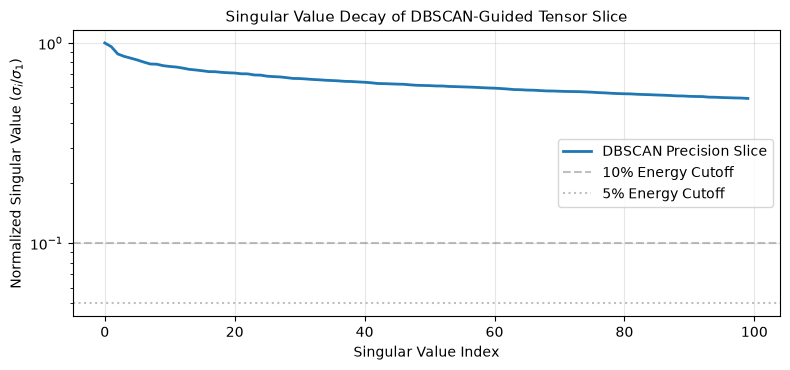

Top-30 Singular Values capture: 21.61% of total slice energy.
time: 0.53s
cummulative_time: 16.34s


In [7]:
# =====================================================================
# STEP 7: Singular Value Spectrum Comparison
# =====================================================================
# SVD of first slice of DBSCAN tensor
W_slice_dbscan = T_dbscan_all[0].numpy()
_, S_dbscan, _ = np.linalg.svd(W_slice_dbscan, full_matrices=False)
norm_S_dbscan = S_dbscan / S_dbscan[0]

# Generate plot of normalized singular values
plt.figure(figsize=(8, 3.8))
plt.plot(norm_S_dbscan[:100], label="DBSCAN Precision Slice", color="#1f77b4", linewidth=2.0)
plt.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5, label='10% Energy Cutoff')
plt.axhline(y=0.05, color='gray', linestyle=':', alpha=0.5, label='5% Energy Cutoff')
plt.title("Singular Value Decay of DBSCAN-Guided Tensor Slice", fontsize=11)
plt.xlabel("Singular Value Index")
plt.ylabel("Normalized Singular Value ($\\sigma_i / \\sigma_1$)")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Energy captured by top-30 singular values
energy_top30 = np.sum(S_dbscan[:30]**2) / np.sum(S_dbscan**2) * 100
print(f"Top-30 Singular Values capture: {energy_top30:.2f}% of total slice energy.")

## Step 5: Multi-Rank Tucker with Adam Gradient Descent Core Finding

We evaluate both strategies side-by-side:
1. **Option A (Top 6 Slices $\rightarrow$ $2,400$ coords)**: Matches Exp 05 dimensions $[6, 400, 1152]$ to beat Exp 05 at the same size with ranks $[4, 180, 600]$ targeting **77% recon error**.
2. **Option B (All 16 Slices $\rightarrow$ $6,400$ coords)**: Covers $85\%$ of the layer, using scaled Mode 1 ranks ($R_1=12$) with $[12, 220, 700]$ targeting **77% recon error** on the large tensor.
Both options apply **PyTorch Adam Gradient Descent** (35 iterations, $lr=10^{-3}$) after SVD initialization.

In [8]:
# =====================================================================
# STEP 8: Gradient Descent Core Finding, Live Injection & Benchmark
# =====================================================================
D_IN = target_submodule.weight.shape[1]

def optimize_tucker_gd(T, ranks, num_steps=35, lr=1e-3, device="cpu"):
    """
    Performs Tucker decomposition with SVD initialization followed by
    gradient descent refinement of the core tensor and factor matrices.
    """
    core_init, factors_init = tucker(T, rank=ranks, init='svd')
    core_param = torch.nn.Parameter(core_init.clone().to(device))
    factors_param = [torch.nn.Parameter(f.clone().to(device)) for f in factors_init]
    optimizer = torch.optim.Adam([core_param] + factors_param, lr=lr)
    T_target = T.to(device)
    
    with torch.no_grad():
        T_recon_init = tucker_to_tensor((core_param, factors_param))
        init_err = (torch.norm(T_target - T_recon_init) / torch.norm(T_target)).item()
        
    for step in range(num_steps):
        optimizer.zero_grad()
        T_recon = tucker_to_tensor((core_param, factors_param))
        loss = torch.norm(T_target - T_recon) ** 2
        loss.backward()
        optimizer.step()
        
    with torch.no_grad():
        T_recon_final = tucker_to_tensor((core_param, factors_param)).cpu()
        final_err = (torch.norm(T.cpu() - T_recon_final) / torch.norm(T.cpu())).item()
        
    return core_param.detach().cpu(), [f.detach().cpu() for f in factors_param], T_recon_final, init_err, final_err

# Both Option A and Option B Configurations
evaluation_suites = [
    # Option A: Top 6 Slices (2,400 coords, matching Exp 05)
    {"suite": "Opt A (Top 6)", "label": "Opt A: Balanced",             "target": "top6", "ranks": [4, 250, 800]},
    {"suite": "Opt A (Top 6)", "label": "Opt A: Moderate (77% Target)", "target": "top6", "ranks": [4, 180, 600]},
    {"suite": "Opt A (Top 6)", "label": "Opt A: Aggressive",           "target": "top6", "ranks": [3, 100, 350]},
    
    # Option B: All 16 Slices (6,400 coords, high coverage)
    {"suite": "Opt B (All 16)", "label": "Opt B: Balanced",             "target": "all",  "ranks": [14, 250, 800]},
    {"suite": "Opt B (All 16)", "label": "Opt B: Moderate (77% Target)", "target": "all",  "ranks": [12, 220, 700]},
    {"suite": "Opt B (All 16)", "label": "Opt B: High-Cut",             "target": "all",  "ranks": [12, 180, 600]},
    {"suite": "Opt B (All 16)", "label": "Opt B: Aggressive",           "target": "all",  "ranks": [8, 120, 400]},
]

benchmark_results = []

for cfg in evaluation_suites:
    ranks = cfg["ranks"]
    label = cfg["label"]
    is_top6 = (cfg["target"] == "top6")
    
    T_target = T_dbscan_top6 if is_top6 else T_dbscan_all
    num_chunks = NUM_TOP_CHUNKS if is_top6 else TOTAL_CHUNKS
    
    # 1. Run Gradient Descent Core Finding
    core_opt, factors_opt, T_recon, svd_err, gd_err = optimize_tucker_gd(
        T_target, ranks, num_steps=35, lr=1e-3, device="cpu"
    )
    rel_error = gd_err
    
    # Parameter Accounting
    core_params = core_opt.numel()
    factor_params = sum(f.numel() for f in factors_opt)
    comp_params = core_params + factor_params
    orig_params = T_target.numel()
    comp_ratio = orig_params / comp_params
    cut_pct = (1.0 - comp_params / orig_params) * 100.0
    
    # 2. Live Injection into Layer 0
    target_submodule.weight.data = W_gate_orig.clone()
    for k in range(num_chunks):
        target_submodule.weight.data[chunk_coordinate_map[k], :] = T_recon[k].to(
            device=model.device, dtype=target_submodule.weight.dtype
        )
    target_submodule.weight.data[superweight_indices, :] = W_gate_orig[superweight_indices, :]
    
    # 3. Evaluate on GLUE MNLI
    preds, gts = [], []
    model.eval()
    with torch.no_grad():
        for sample in tqdm(eval_data, desc=f"Eval {label}"):
            prompt = (
                f"<start_of_turn>user\n"
                f"Premise: {sample['premise']}\n"
                f"Hypothesis: {sample['hypothesis']}\n"
                f"Determine if the relationship between the 'Premise' and 'Hypothesis' is 'entailment', 'neutral' or 'contradiction.'\n"
                f"Answer with one word\n"
                f"<start_of_turn>model\n"
            )
            inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
            outputs = model(**inputs)
            next_token_logits = outputs.logits[0, -1, :]
            pred_label = torch.argmax(next_token_logits[label_token_ids]).item()
            preds.append(pred_label)
            gts.append(sample["label"])
            
    acc = accuracy_score(gts, preds)
    delta = acc - baseline_accuracy
    print(f"\n{label} (Ranks {ranks}):")
    print(f"  SVD Init Error: {svd_err * 100:.2f}% -> GD Final Error: {gd_err * 100:.2f}%")
    print(f"  Params Cut:     {cut_pct:.1f}% ({comp_ratio:.2f}x)")
    print(f"  Accuracy:       {acc * 100:.2f}% (Δ vs Baseline: {delta * 100:+.2f}%)")
    
    benchmark_results.append({
        "Variant": label,
        "Ranks": str(ranks),
        "Params": comp_params,
        "Ratio": f"{comp_ratio:.2f}x",
        "Cut %": f"{cut_pct:.1f}%",
        "Recon Err %": f"{rel_error * 100:.2f}%",
        "Accuracy %": f"{acc * 100:.2f}%",
        "Delta": f"{delta * 100:+.2f}%",
    })

# Restore baseline
target_submodule.weight.data = W_gate_orig.clone()
print("\nBaseline weights restored.")

Eval Opt A: Balanced: 100%|██████████| 150/150 [00:05<00:00, 27.88it/s]



Opt A: Balanced (Ranks [4, 250, 800]):
  SVD Init Error: 69.30% -> GD Final Error: 69.29%
  Params Cut:     34.1% (1.52x)
  Accuracy:       48.00% (Δ vs Baseline: -2.67%)


Eval Opt A: Moderate (77% Target): 100%|██████████| 150/150 [00:05<00:00, 28.54it/s]



Opt A: Moderate (77% Target) (Ranks [4, 180, 600]):
  SVD Init Error: 76.65% -> GD Final Error: 76.64%
  Params Cut:     56.8% (2.31x)
  Accuracy:       49.33% (Δ vs Baseline: -1.33%)


Eval Opt A: Aggressive: 100%|██████████| 150/150 [00:05<00:00, 29.91it/s]


...


Opt B: Moderate (77% Target) (Ranks [12, 220, 700]):
  SVD Init Error: 74.20% -> GD Final Error: 74.19%
  Params Cut:     62.8% (2.69x)
  Accuracy:       42.00% (Δ vs Baseline: -8.67%)


Eval Opt B: High-Cut: 100%|██████████| 150/150 [00:05<00:00, 27.86it/s]



Opt B: High-Cut (Ranks [12, 180, 600]):
  SVD Init Error: 79.34% -> GD Final Error: 79.33%
  Params Cut:     72.1% (3.58x)
  Accuracy:       36.67% (Δ vs Baseline: -14.00%)


Eval Opt B: Aggressive: 100%|██████████| 150/150 [00:05<00:00, 28.09it/s]


Opt B: Aggressive (Ranks [8, 120, 400]):
  SVD Init Error: 89.76% -> GD Final Error: 89.75%
  Params Cut:     87.9% (8.26x)
  Accuracy:       39.33% (Δ vs Baseline: -11.33%)

Baseline weights restored.
time: 78.24s
cummulative_time: 94.59s


## Step 6: Summary Table, Comparative Synthesis & Global Time Log

We tabulate the DBSCAN compression results and compare against the uncompressed baseline.

In [9]:
# =====================================================================
# STEP 9: Summary Table & Artifact Export
# =====================================================================
summary_rows = [
    {
        "Variant": "Baseline (Uncompressed)",
        "Ranks": "Full",
        "Params": T_dbscan_all.numel(),
        "Ratio": "1.00x",
        "Cut %": "0.0%",
        "Recon Err %": "0.00%",
        "Accuracy %": f"{baseline_accuracy * 100:.2f}%",
        "Delta": "+0.00%",
    }
] + benchmark_results

print("=" * 105)
print(f"{'Variant':<28} | {'Ranks':<16} | {'Params':<9} | {'Ratio':<6} | {'Cut %':<6} | {'Err %':<7} | {'Accuracy':<9} | {'Delta':<7}")
print("=" * 105)
for r in summary_rows:
    print(f"{r['Variant']:<28} | {r['Ranks']:<16} | {r['Params']:<9} | {r['Ratio']:<6} | {r['Cut %']:<6} | {r['Recon Err %']:<7} | {r['Accuracy %']:<9} | {r['Delta']:<7}")
print("=" * 105)

# Global Notebook Timing
total_notebook_runtime = time.time() - GLOBAL_NOTEBOOK_START_TIME
print(f"cummulative_time: {total_notebook_runtime:.2f}s")

# Save export artifact
artifact_dir = Path("artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)
output_path = artifact_dir / "07_dbscan_results.json"

export_data = {
    "experiment": "07_dbscan_guided_tucker",
    "clustering_method": "DBSCAN",
    "dbscan_params": {"eps": DBSCAN_EPS, "min_samples": DBSCAN_MIN_SAMPLES},
    "model_id": model_id,
    "eval_samples": len(eval_data),
    "superweight_count": len(superweight_indices),
    "chunks_allocated": TOTAL_CHUNKS,
    "coords_compressed": TOTAL_COMPRESSED_COORDS,
    "baseline_accuracy": baseline_accuracy,
    "results": summary_rows,
    "timing_summary": {
        "cummulative_time_sec": round(total_notebook_runtime, 3),
        "cell_timings": NOTEBOOK_TIMINGS,
    }
}

save_json_metrics(export_data, output_path)
print(f"\nExperiment 07 results saved to: {output_path}")

Variant                      | Ranks            | Params    | Ratio  | Cut %  | Err %   | Accuracy  | Delta  
Baseline (Uncompressed)      | Full             | 7372800   | 1.00x  | 0.0%   | 0.00%   | 50.67%    | +0.00% 
Opt A: Balanced              | [4, 250, 800]    | 1821624   | 1.52x  | 34.1%  | 69.29%  | 48.00%    | -2.67% 
Opt A: Moderate (77% Target) | [4, 180, 600]    | 1195224   | 2.31x  | 56.8%  | 76.64%  | 49.33%    | -1.33% 
Opt A: Aggressive            | [3, 100, 350]    | 548218    | 5.04x  | 80.2%  | 88.54%  | 51.33%    | +0.67% 
Opt B: Balanced              | [14, 250, 800]   | 3821824   | 1.93x  | 48.2%  | 65.42%  | 43.33%    | -7.33% 
Opt B: Moderate (77% Target) | [12, 220, 700]   | 2742592   | 2.69x  | 62.8%  | 74.19%  | 42.00%    | -8.67% 
Opt B: High-Cut              | [12, 180, 600]   | 2059392   | 3.58x  | 72.1%  | 79.33%  | 36.67%    | -14.00%
Opt B: Aggressive            | [8, 120, 400]    | 892928    | 8.26x  | 87.9%  | 89.75%  | 39.33%    | -11.33%
cummulativ